### Making graphene visible

arXiv:0705.0259v3

Made with Claude Sonnet 4.5

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Wavelength in nanometers
wavelength_data = np.array([380, 400, 450, 500, 550, 600, 650, 700, 750])

# n1: Constant complex refractive index (wavelength independent)
n1 = 2.6 - 1.3j

# n2: Silicon dioxide (SiO₂)
n2_data = np.array([1.470, 1.468, 1.462, 1.458, 1.455, 1.453, 1.451, 1.450, 1.449]) + 0j

# n3: Silicon (Si)
n3_real = np.array([5.60, 5.57, 4.93, 4.27, 4.05, 3.94, 3.85, 3.78, 3.73])
n3_imag = np.array([0.53, 0.39, 0.16, 0.082, 0.038, 0.019, 0.010, 0.0061, 0.0042])
n3_data = n3_real + 1j * n3_imag


# Other parameters
n0 = 1  # air
d1 = 0.34  # nm (graphene thickness)

In [3]:
def compute_intensity(n1_layer, d2, wavelength):
    """
    Compute reflected intensity I as a function of n1 (graphene layer index).
    
    Parameters:
    -----------
    n1_layer : complex
        Refractive index of layer 1 (graphene or air)
    d2 : float or array
        Thickness of SiO2 layer in nm
    wavelength : float or array
        Wavelength in nm
    
    Returns:
    --------
    I : reflected intensity
    """
    
    # Interpolate n2 and n3 for the given wavelength
    n2 = np.interp(wavelength, wavelength_data, n2_data.real) + 0j
    n3 = np.interp(wavelength, wavelength_data, n3_data.real) + 1j * np.interp(wavelength, wavelength_data, n3_data.imag)
    
    # Fresnel reflection coefficients (Eq. 2)
    r1 = (n0 - n1_layer) / (n0 + n1_layer)
    r2 = (n1_layer - n2) / (n1_layer + n2)
    r3 = (n2 - n3) / (n2 + n3)
    
    # Phase shifts
    Phi1 = 2 * np.pi * n1_layer * d1 / wavelength
    Phi2 = 2 * np.pi * n2 * d2 / wavelength
    
    # Intensity (Eq. 1)
    term1 = r1 * np.exp(1j*(Phi1 + Phi2)) + r2 * np.exp(-1j*(Phi1 - Phi2))
    term2 = r3 * np.exp(-1j*(Phi1 + Phi2)) + r1*r2*r3 * np.exp(1j*(Phi1 - Phi2))
    term3 = np.exp(1j*(Phi1 + Phi2)) + r1*r2 * np.exp(-1j*(Phi1 - Phi2))
    term4 = r1*r3 * np.exp(-1j*(Phi1 + Phi2)) + r2*r3 * np.exp(1j*(Phi1 - Phi2))
    
    I = np.abs((term1 + term2) / (term3 + term4))**2
    
    return I

In [4]:
def compute_contrast(d2, wavelength):
    """
    Compute contrast C as a function of d2 (thickness) and wavelength.
    
    Parameters:
    -----------
    d2 : float or array
        Thickness of SiO2 layer in nm
    wavelength : float or array
        Wavelength in nm
    
    Returns:
    --------
    C : contrast value(s)
    """
    
    # Intensity with graphene (n1 = 2.6 - 1.3j)
    I_with_graphene = compute_intensity(n1, d2, wavelength)
    
    # Intensity without graphene (n1 = n0 = 1)
    I_without_graphene = compute_intensity(n0, d2, wavelength)
    
    # Contrast (Eq. 3)
    C = (I_without_graphene - I_with_graphene) / I_without_graphene
    
    return C

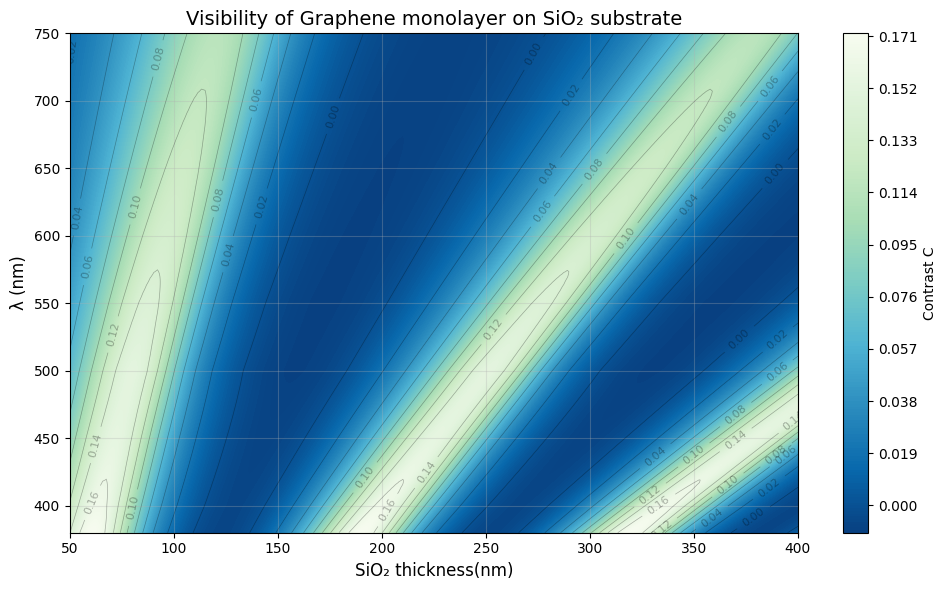

In [6]:
# Create meshgrid for wavelength and d2
wavelength_range = np.linspace(380, 750, 200)  # nm (visible spectrum)
d2_range = np.linspace(50, 400, 200)  # nm (SiO2 thickness)

D2, Lambda = np.meshgrid(d2_range, wavelength_range)

# Compute contrast for all combinations
C = np.zeros_like(Lambda)
for i in range(len(wavelength_range)):
    for j in range(len(d2_range)):
        C[i, j] = compute_contrast(d2_range[j], wavelength_range[i])

# Create the heatmap with swapped axes
fig = plt.figure(figsize=(10, 6))
im = plt.contourf(D2, Lambda, C, levels=200, cmap='GnBu_r')
plt.colorbar(im, label='Contrast C')
plt.xlabel('SiO₂ thickness(nm)', fontsize=12)
plt.ylabel('λ (nm)', fontsize=12)
plt.title('Visibility of Graphene monolayer on SiO₂ substrate', fontsize=14)
plt.grid(True, alpha=0.3)

# Add contour lines
contours = plt.contour(D2, Lambda, C, levels=10, colors='black', alpha=0.3, linewidths=0.5)
plt.clabel(contours, inline=True, fontsize=8)

plt.tight_layout()
plt.show()

In [7]:
savefig = True
if savefig:
    fig.savefig('graphene_contrast_heatmap.png', dpi=300)